## Tutorial: Membrane mechanics

This tutorial uses `triangulax` to study the mechanics of membranes. We numerically represent a membrane as a triangular mesh, and finds its mechanically balanced configuration by energy minimization, using automatic differentiation to calculate energy gradients.

In [1]:
import numpy as np
from scipy import sparse, optimize
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import meshplot

from functools import partial

from tqdm.notebook import tqdm

In [2]:
import jax.numpy as jnp
import jax

In [3]:
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", True)

In [4]:
import lineax
import optimistix

In [5]:
from triangulax import geometry as geom
from triangulax import adjacency as adj
from triangulax import linops as lin
from triangulax.triangular import TriMesh
from triangulax.mesh import HeMesh, GeomMesh
from triangulax import linops

## Minimal surfaces

As a first example, let's consider a membrane $\mathcal{M}$ whose energy is dominated by surface tension, so the energy is proportional to the membrane area $E_A = \int_{\mathcal{M}} dA$. Note that moving vertices _within_ the plane of the mesh does not change the total area/energy (physically, this is because membranes are fluid in-plane, rather than thin elastic sheets). This has important numerical consequences: we will want to arrange the mesh vertices so as to avoid a highly distorted mesh with very stretched triangles.

A nice algorithm by [Pinkall and Poitier](https://projecteuclid.org/journalArticle/Download?urlId=em%2F1062620735) takes care of this problem. It uses the discretized Laplacian which we already used in the previous notebook for the heat equation. 
The idea is that to minimize the area, the position of a vertex $\mathbf{v}_i$ should be equal to the (geometry-weighted) average of its neighbors, and therefore $\Delta \mathbf{v}_i = 0$. The resulting iterative algorithm works as follows.

1. Given the vertex-positions $\mathbf{v}_i^{(t)}$ at step $t$, compute the cotan-Laplacian matrix $\Delta^{(t)}_{ij}$
2. Solve $\Delta^{(t)}_{ij} \cdot \mathbf{v}_i^{(t+1)} =0$, subject to fixed boundary conditions.

  o flat_tri_ecmc


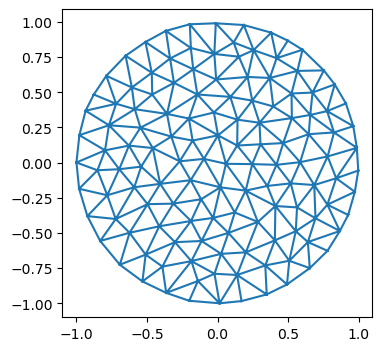

In [6]:
# let's load a simple test mesh

trimesh = TriMesh.read_obj("../test_meshes/disk.obj", dim=3)
hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

fig = plt.figure(figsize=(4,4))
plt.triplot(*trimesh.vertices[:,:2].T, trimesh.faces)
plt.axis("equal");

In [7]:
# let's impose some boundary conditions on the disk mesh - think of this as finding the shape of a "soap film"
# with a given boundary curve.

bdry_verts = np.where(hemesh.is_bdry)[0]
interior_verts = np.where(~hemesh.is_bdry)[0]

phi_bdry = np.atan2(*trimesh.vertices[bdry_verts, :2].T)
h = 0.5*np.sin(2*phi_bdry)
bdry_pos = np.array(trimesh.vertices[bdry_verts, :])
bdry_pos[:, -1] = h

vertices_bdry_imposed = np.copy(trimesh.vertices)
vertices_bdry_imposed[bdry_verts] = bdry_pos

In [8]:
# the non-optimized membrane is pretty creased

meshplot.plot(vertices_bdry_imposed, hemesh.faces, shading={"wireframe":False}, return_plot=True)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.001874…

In [10]:
# compute the area of the initial configuration - this is the energy we will minimize
initial_area = geom.get_triangle_areas(vertices_bdry_imposed, hemesh).sum()
print(f"Initial area: {initial_area:.4f}")

Initial area: 4.3650


In [11]:
# let's check the cotan-Laplacian gives us the area via A = 1/2 * v^T L v, where v are the vertex positions

L = linops.cotan_laplace_sparse(vertices_bdry_imposed, hemesh)
area_L = jnp.diag(vertices_bdry_imposed.T.dot(L @ vertices_bdry_imposed)).sum() /2

print(f"Initial area from Laplace operator: {area_L:.4f}")

Initial area from Laplace operator: -4.3650


In [12]:
# Let's use the iterative Pinkall-Poitier method to find the mininum energy configuration.

vertices_iterated = [np.copy(vertices_bdry_imposed)] 

for t in range(10):
    L = linops.bcoo_to_scipy(linops.cotan_laplace_sparse(vertices_iterated[-1], hemesh)) # compute Laplace matrix

    # impose boundary conditions by splitting the Laplace matrix into interior and boundary vertices
    L_ii = L[interior_verts, :][:, interior_verts] 
    L_ib = L[interior_verts, :][:, bdry_verts]
    bcs = vertices_bdry_imposed[bdry_verts,:]
    
    new_vertices = np.zeros_like(vertices_iterated[-1])
    new_vertices[bdry_verts] = bcs

    solution = np.stack([sparse.linalg.spsolve(-L_ii, L_ib.dot(bc)) for bc in bcs.T], axis=-1) # iterate over x/y/z coordinates
    new_vertices[interior_verts] = solution
    vertices_iterated.append(new_vertices)

In [13]:
# as a result of the optimization, we get an area-minimizing "Pringles" surface

meshplot.plot(vertices_iterated[-1], hemesh.faces, shading={"wireframe":True}, return_plot=True)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.001874…

In [14]:
final_area = geom.get_triangle_areas(vertices_iterated[-1], hemesh).sum()
print(f"Initial area: {initial_area:.4f}", f"Final area: {final_area:.4f}")

Initial area: 4.3650 Final area: 3.7981


In [15]:
# the gradient of the area is very small after optimization:   

def get_area(vertices, hemesh):
    return geom.get_triangle_areas(vertices, hemesh).sum()

(jnp.linalg.norm(jax.grad(get_area)(vertices_iterated[0], hemesh), axis=-1)[interior_verts].mean(),
 jnp.linalg.norm(jax.grad(get_area)(vertices_iterated[-1], hemesh), axis=-1)[interior_verts].mean())

(Array(0.06015605, dtype=float64), Array(0.00068703, dtype=float64))

### Helfrich energy

Next, let's consider a membrane for which the surface tension is negligible. This is the case for many of the lipid bilayer membranes that make up the cell and its interior organelles. Instead, the energy is dominated by _bending_.

The _Helfrich energy_ is an elegant, geometric model of bending energy. It uses the mean and Gaussian curvatures $H, K$ of the surface $\mathcal{M}$ (see [wikipedia](https://en.wikipedia.org/wiki/Differential_geometry_of_surfaces), and [Crane, Chpt. 5](https://www.cs.cmu.edu/~kmcrane/Projects/DDG/paper.pdf) for how to discretize $H, K$ on a triangular mesh).
The energy reads:

$$E_H  =\int dA \left( \frac{\kappa_H}{2}(H-H_0)^2 + \kappa_G K \right) $$

If the surface is closed, the $\int K$-term is a topological invariant and can be dropped (and we will do so here). 
A nonzero _spontaneous curvature_ $H_0$ means that the membrane "prefers" to be curved; this can result, for instance, from molecules that bind to the membrane.

The exact mean curvature can be computed from the Laplace operator, applied to the vertex positions $\mathbf{v}$ as $\Delta\mathbf{v} = 2H\mathbf{n}$, where $\mathbf{n}$ is the surface normal. However, to compute the curvature $H$ numerically, we use the _dihedral angles_ $\theta_{ij}$ of each edge $ij$: the angles between the normal vectors of adjacent triangles. The mean curvature at vertex $i$ can be approximated by
$$H_i = \frac{1}{4a_i} \sum_{j\sim i} \ell_{ij} \theta_{ij} $$
where the sum is over all $j$ neighboring $i$, and $a_i$ is the (Voronoi) area around vertex $i$.

In [58]:
# let's load a sphere as a test mesh for the Helfrich energy

trimesh = TriMesh.read_obj("../test_meshes/sphere.obj", dim=3) # sphere_fine sphere
hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

  o Icosphere


In [59]:
meshplot.plot(trimesh.vertices, hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [128]:
# let's define the discrete Helfrich energy. For this, we need the mean curvature

@jax.jit
def get_mean_curvature_dihedral(vertices, hemesh):

    """Compute mean curvature of triangulated mesh using cotan laplacian and voronoi areas"""

    dihedral_angles = geom.get_dihedral_angles(vertices, hemesh)
    edge_lengths = geom.get_he_length(vertices, hemesh)
    cell_areas = geom.get_voronoi_areas(vertices, hemesh)
    return  1/4 * adj.sum_he_to_vertex_incoming(hemesh, dihedral_angles*edge_lengths) / cell_areas

@jax.jit
def get_mean_curvature_laplace(vertices, hemesh):

    """Compute mean curvature of triangulated mesh using cotan laplacian and voronoi areas"""
    l_vec = lin.compute_cotan_laplace(vertices, hemesh, vertices)
    n_vec = geom.get_vertex_normals(vertices, hemesh)
    cell_areas = geom.get_voronoi_areas(vertices, hemesh)
    return -jnp.linalg.vecdot(l_vec, n_vec) / (2* cell_areas)

@jax.jit
def get_helfrich_energy(vertices, args):
    """Compute the discrete Helfrich energy of a triangulated surface. args = (hemesh, H0, kappa)"""
    hemesh, H0, kappa = args

    H = get_mean_curvature_laplace(vertices, hemesh) # get_mean_curvature_laplace get_mean_curvature_dihedral
    cell_areas = geom.get_voronoi_areas(vertices, hemesh)
    return (kappa/2) * ((H - H0) **2 * cell_areas).sum()


# let's also define the "conformal" energy, which penalizes shear deformation of individual triangles, but not area changes.


In [129]:
# let's check the mean-curvature of the sphere using the Laplace operator - this should be constant across all vertices

vertices = trimesh.vertices
H_laplace = get_mean_curvature_laplace(vertices, hemesh)
H_dihedral = get_mean_curvature_dihedral(vertices, hemesh)


# let's compute the radius of the sphere:
R = jnp.linalg.norm(vertices-vertices.mean(axis=0), axis=-1).mean()
print("H (Laplace)", H_laplace.mean(), "H - 1/R:", jnp.abs(H_laplace - 1/R).mean())
print("H (Dihedral)", H_dihedral.mean(), "H - 1/R:", jnp.abs(H_dihedral - 1/R).mean())

H (Laplace) 0.9999999396050825 H - 1/R: 1.642197383279145e-06
H (Dihedral) 1.0508797410359099 H - 1/R: 0.05087976509886655


In [130]:
# let's compare our implementation to that of the geometry library IGL

import igl

l = igl.cotmatrix(vertices, hemesh.faces)
m = igl.massmatrix(vertices, hemesh.faces, igl.MASSMATRIX_TYPE_VORONOI)

minv = sparse.diags(1 / m.diagonal())
hn = -minv.dot(l.dot(vertices))
h = np.linalg.norm(hn, axis=1)

h.mean()/2

np.float64(0.9999999396059016)

In [131]:
args = (hemesh, 0, 1)
# exact helfrich for a sphere is 2*pi, here smaller due to discretization error. The energy is scale invariant.
get_helfrich_energy(trimesh.vertices, args), get_helfrich_energy(2*trimesh.vertices, args)

(Array(5.8329657, dtype=float64), Array(5.8329657, dtype=float64))

In [132]:
# now, let's deform the sphere and minimize the Helfrich energy to find the equilibrium shape.

deformed_vertices = trimesh.vertices.at[:, 1].add(1*trimesh.vertices[:, 1]**3)
deformed_vertices = trimesh.vertices.at[:, 2].add(1*trimesh.vertices[:, 0]**3)

print("Minimum vs deformed energy:", get_helfrich_energy(trimesh.vertices, args),
                                     get_helfrich_energy(deformed_vertices, args))

Minimum vs deformed energy: 5.832965695813845 7.342784645258564


In [133]:
meshplot.plot(deformed_vertices, hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

#### Nonlinear minimization

To minimize the energy, we can use one of many non-linear minimization algorithms, all of which use the gradient $\nabla E_H$ which we can compute using JAX. Here, we use the JAX-based optimization library `optimistix`.

In [137]:
solver = optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)

y0 = deformed_vertices
args = (hemesh, 0, 1) 

sol = optimistix.minimise(get_helfrich_energy, solver, y0, args, max_steps=20000, throw=False)
vertices_final = sol.value

# initially converges to correct solution, but eventually, the shape becomes degenerat

In [138]:
jnp.linalg.norm(y0-sol.value, axis=-1).mean(), jnp.linalg.norm(y0-trimesh.vertices, axis=-1).mean()

(Array(0.06861081, dtype=float64), Array(0.25017407, dtype=float64))

In [139]:
print("Initial/final/minimal energy:", get_helfrich_energy(y0, args),
                                       get_helfrich_energy(sol.value, args),
                                       get_helfrich_energy(trimesh.vertices, args))


# that's no good... the vertices have hardly moved, yet the energy decreased a lot.
# at points where the mesh is highly deformed, the energy becomes poorly behaved.
# need to fix. Does it have to do with Voronoi areas? 

# Overall, it appears that the normal + tangential area method is the most principled approach.

Initial/final/minimal energy: 7.342784645258564 4.824873875545231 5.832965695813845


In [140]:
# compute the norm of the energy gradient
grad_norm = jnp.linalg.norm(jax.grad(get_helfrich_energy)(y0, args), axis=-1)

In [141]:
p = meshplot.plot(sol.value, hemesh.faces, shading={"wireframe":True}, return_plot=True)
p.add_mesh(y0 + np.array([0, 0, 3]), hemesh.faces, np.array(grad_norm), shading={"wireframe":True})


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

1

## Constrained minimization

Much of the physics of membranes arises from balancing the Helfrich bending energy with constraints on the volume $V$ and area $A$ of the membrane.
We can include these constraints via two Lagrange multipliers $\lambda, p$, surface tension and pressure:   

$$\mathcal{L} = E_H - \lambda (A-A_0) -p (V-V_0) $$

Minimization under the boundary constraint is equivalent to stationarity of the Lagrangian:

$$\nabla_\lambda \mathcal{L} = 0 \quad \mathrm{and} \quad \nabla_{\mathbf{v}} \mathcal{L} = 0 $$

Finding these stationary points - the aim of _numerical constrained minimization_ - can be quite challenging.
If the number of constraints (here, $2$) is small compared to the number of variables (here, $3\#\mathrm{vertices}$), _augmented Lagrangian methods_ are a suitable approach [(Nocedal & Wright, 2006)](https://link.springer.com/book/10.1007/978-0-387-40065-5).


Let's combine all constraints into a vectorial function $\mathbf{c}(\mathbf{x})$ so that $\mathbf{c}(\mathbf{x})=0$ when the constraint is fulfilled. All Lagrange multipliers are packaged into a vector $\lambda$. The _augmented Lagrangian_ $\mathcal{L}_A$ adds a quadratic penalty for constraint violations, with strength $\mu$:

$$\mathcal{L}_A = E(\mathbf{x}) -\lambda^T \cdot\mathbf{c}(\mathbf{x}) + \mu |\mathbf{c}(\mathbf{x})|^2$$

The AL method now iteratively (1) minimizes $\mathcal{L}_A$ w.r.t. to the variables $\mathbf{x}$ and (2) updates the Lagrange multiplier $\lambda$ and penalty strength $\mu$. The big advantage of the AL method compared to the naive approach of using only a penalty for constraint violation is that $\mu$ does not need to be increased to large values, which generally leads to numerical difficulties.

In pseudo-code, the AL method works like this:
```
Initialize μ > 0, tolerance τ > 0, starting points x and λ:
for k = 0, 1, 2, . . .
    Update x: x = minimizer of LA(·, λ; μ) with tolerance τ, starting from x   
    if convergence test for Lagrangian stationarity is satisfied:
        return x
    Update Lagrange multipliers: λ =  λ - μ * c(x)
    Increase penalty parameter μ
    Select new tolerance
```

In [ ]:
def get_tetrahedron_volume(a, b, c):
    """Volume of tetrahedron defined by side vectors a, b, c"""
    return jnp.linalg.vecdot(a, jnp.cross(b,c)) / 6

def get_volume(vertices, hemesh):
    """Signed volume of a closed triangulated surface (sums tetrahedron volumes relative to the origin)."""
    v0, v1, v2 = vertices[hemesh.faces.T]
    return get_tetrahedron_volume(v0, v1, v2).sum()

def get_area(vertices, hemesh):
    """Total surface area."""
    return geom.get_triangle_areas(vertices, hemesh).sum()

# verify on the sphere mesh
A_sphere = get_area(trimesh.vertices, hemesh)
V_sphere = get_volume(trimesh.vertices, hemesh)
print(f"Sphere area: {A_sphere:.4f} (exact 4π = {4*jnp.pi:.4f})")
print(f"Sphere volume: {V_sphere:.4f} (exact 4π/3 = {4*jnp.pi/3:.4f})")

Sphere area: 11.6659 (exact 4π = 12.5664)
Sphere volume: 3.6587 (exact 4π/3 = 4.1888)


In [335]:
# let's first try a simple penalty menthod to enfore the constraints.

@jax.jit
def get_helfrich_energy_with_penalty(vertices, args):
    """Compute the discrete Helfrich energy of a triangulated surface with a penalty method.
    args = (hemesh, H0, kappa, mu, A0, V0)"""
    hemesh, H0, kappa, mu, A0, V0 = args
    E = get_helfrich_energy(vertices, (hemesh, H0, kappa))
    contraint_penalty = mu/2 *((get_area(vertices, hemesh) - A0)**2 + (get_volume(vertices, hemesh) - V0)**2)
    #area_penalty = 50 * geom.get_triangle_areas(vertices, hemesh).sum()
    # area_penalty = ((geom.get_triangle_areas(vertices, hemesh)-0.146)**2).sum()
    return E + contraint_penalty   #+ area_penalty

In [341]:
A0 = get_area(trimesh.vertices, hemesh)
V0 = 0.9 * get_volume(trimesh.vertices, hemesh)
kappa, H0 = 1.0, 0.0
mu = 100.0
args = (hemesh, H0, kappa, mu, A0, V0)

# small perturbation to break spherical symmetry
#y0 = trimesh.vertices + 0.02 * jax.random.normal(jax.random.PRNGKey(0), trimesh.vertices.shape)
y0 = deformed_vertices


In [342]:
solver = optimistix.NonlinearCG(rtol=1e-8, atol=1e-8) # BFGS is generally a recipe for trouble

sol = optimistix.minimise(get_helfrich_energy_with_penalty, solver, y0, args, max_steps=2000, throw=False)
vertices_final = sol.value


In [343]:
get_area(vertices_final, hemesh)/A0, get_volume(vertices_final, hemesh)/V0

(Array(0.99847313, dtype=float64), Array(1.01169332, dtype=float64))

In [344]:
# works but the mesh becomes poor quality. need to add some term to prevent poor-quality triangles.
# one option is to add a per-triangle area penalty (not quit physical)
# more precisely, one can add a Dirichlet energy term (get's absorved into overall area Lagrange multiplier) Does that reall change anyting?
#

In [345]:
meshplot.plot(vertices_final, hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [275]:
@jax.jit
def augmented_lagrangian(vertices, args):
    """Augmented Lagrangian: E_H - λᵀc + (μ/2)|c|², where c = [A-A0, V-V0]."""
    hemesh, H0, kappa, lam, mu, A0, V0 = args
    E = get_helfrich_energy(vertices, (hemesh, H0, kappa))
    c = jnp.array([get_area(vertices, hemesh) - A0,
                    get_volume(vertices, hemesh) - V0])
    area_penalty = ((geom.get_triangle_areas(vertices, hemesh)-0.146)**2).sum()
    return E - lam @ c + (mu / 2) * (c @ c) + area_penalty

In [289]:
def al_minimize(vertices, hemesh, H0, kappa, A0, V0,
                mu0=1.0, mu_growth=1.5, max_outer=10, tol=1e-4, max_inner=500):
    """Augmented Lagrangian method for constrained Helfrich energy minimization."""
    lam = jnp.zeros(2)
    mu = mu0
    solver = optimistix.NonlinearCG(rtol=1e-5, atol=1e-5)

    for k in range(max_outer):
        args = (hemesh, H0, kappa, lam, mu, A0, V0)
        sol = optimistix.minimise(augmented_lagrangian, solver, vertices, args,
                                  max_steps=max_inner, throw=False)
        vertices = sol.value

        A = get_area(vertices, hemesh)
        V = get_volume(vertices, hemesh)
        c = jnp.array([A - A0, V - V0])
        E = get_helfrich_energy(vertices, (hemesh, H0, kappa))

        # stationarity of the Lagrangian (μ=0): ∇_v L = 0 and ∇_λ L = -c = 0
        lagrangian_args = (hemesh, H0, kappa, lam, 0.0, A0, V0)
        grad_v = jax.grad(augmented_lagrangian)(vertices, lagrangian_args)
        grad_norm = jnp.sqrt(jnp.sum(grad_v**2) + jnp.sum(c**2))

        print(f"  iter {k:2d} | E_H={E:.4f} | A={A:.4f} (target {A0:.4f}) | "
              f"V={V:.4f} (target {V0:.4f}) | |∇L|={grad_norm:.2e} | μ={mu:.1f}")

        if grad_norm < tol:
            print("Converged!")
            break

        lam = lam - mu * c
        mu = mu * mu_growth

    return vertices, lam

In [290]:
# minimize Helfrich energy of a sphere with constrained area and reduced volume (deflated)

A0 = get_area(trimesh.vertices, hemesh)
V0 = 0.6 * get_volume(trimesh.vertices, hemesh)
kappa, H0 = 1.0, 0.0

# small perturbation to break spherical symmetry
key = jax.random.PRNGKey(0)
v0 = trimesh.vertices + 0.02 * jax.random.normal(key, trimesh.vertices.shape)

print(f"Target: A0={A0:.4f}, V0={V0:.4f}")
print(f"Initial: A={get_area(v0, hemesh):.4f}, V={get_volume(v0, hemesh):.4f}")

v_opt, lam_opt = al_minimize(v0, hemesh, H0, kappa, A0, V0)

Target: A0=11.6659, V0=2.1952
Initial: A=11.6992, V=3.6646
  iter  0 | E_H=6.5829 | A=11.1221 (target 11.6659) | V=3.4060 (target 2.1952) | |∇L|=1.33e+00 | μ=1.0
  iter  1 | E_H=6.5841 | A=11.1126 (target 11.6659) | V=3.4011 (target 2.1952) | |∇L|=1.34e+00 | μ=1.5
  iter  2 | E_H=6.6155 | A=11.1184 (target 11.6659) | V=3.3931 (target 2.1952) | |∇L|=1.37e+00 | μ=2.2
  iter  3 | E_H=6.6155 | A=11.1184 (target 11.6659) | V=3.3931 (target 2.1952) | |∇L|=4.39e+00 | μ=3.4
  iter  4 | E_H=6.6155 | A=11.1184 (target 11.6659) | V=3.3931 (target 2.1952) | |∇L|=1.49e+00 | μ=5.1
  iter  5 | E_H=12.7387 | A=11.7214 (target 11.6659) | V=2.5791 (target 2.1952) | |∇L|=1.71e+02 | μ=7.6
  iter  6 | E_H=12.7386 | A=11.7214 (target 11.6659) | V=2.5791 (target 2.1952) | |∇L|=1.77e+02 | μ=11.4
  iter  7 | E_H=12.7386 | A=11.7214 (target 11.6659) | V=2.5791 (target 2.1952) | |∇L|=1.75e+02 | μ=17.1
  iter  8 | E_H=12.7386 | A=11.7214 (target 11.6659) | V=2.5791 (target 2.1952) | |∇L|=1.73e+02 | μ=25.6
  iter 

In [291]:
# visualize the deflated shape

E_final = get_helfrich_energy(v_opt, (hemesh, H0, kappa))
E_sphere = get_helfrich_energy(trimesh.vertices, (hemesh, H0, kappa))
print(f"Helfrich energy: sphere={E_sphere:.4f}, deflated={E_final:.4f}")
print(f"Final area: {get_area(v_opt, hemesh):.4f} (target {A0:.4f})")
print(f"Final volume: {get_volume(v_opt, hemesh):.4f} (target {V0:.4f})")
print(f"Lagrange multipliers (tension, pressure): {lam_opt}")

meshplot.plot(v_opt, hemesh.faces, shading={"wireframe": True})

Helfrich energy: sphere=6.5831, deflated=12.7386
Final area: 11.7214 (target 11.6659)
Final volume: 2.5791 (target 2.1952)
Lagrange multipliers (tension, pressure): [  1.66632623 -54.26580124]


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0167619…

## Below - work in progress, ignore

### Non-linear optimization

We have found the desired solution, but using a pretty "custom" algorithm. Let's try to use a more general-purpose strategy for constrained non-linear optimization. To do so, we use the method of Lagrange multipliers, and define the Lagrangian

$$\mathcal{L} = \int_{\mathcal{M}} dA - \int_{\partial\mathcal{M}} \lambda(s)^T \cdot (\mathbf{b}(s) - \mathbf{v}(s))$$

where the first term is the mesh area, and the second term forces vertex positions $\mathbf{v}(s)$ at the boundary to lie at the targets $\mathbf{b}(s)$.

Minimization under the boundary constraint is equivalent to stationarity of the Lagrangian:

$$\nabla_\lambda \mathcal{L} = 0 \quad \mathrm{and} \quad \nabla_{\mathbf{v}} \mathcal{L} = 0 $$

We can attempt to solve this non-linear system of equations using the Newton method, or using non-linear least squares.

In [16]:
def get_lagrangian(vertices, lagrange_mult, bdry_verts, bdry_pos, hemesh):
    """Compute the Lagrangian for the area minimization problem with boundary conditions."""
    area = geom.get_triangle_areas(vertices, hemesh).sum()
    lagrange_term = jax.vmap(jnp.dot)(lagrange_mult, vertices[bdry_verts] - bdry_pos).sum()
    return area - lagrange_term

@jax.jit
def stationarity_condition(y, args):
    vertices, lagrange_mult = y
    v_term = jax.grad(get_lagrangian, argnums=0)(vertices, lagrange_mult, *args)
    l_term = jax.grad(get_lagrangian, argnums=1)(vertices, lagrange_mult, *args)

    return (v_term, l_term)


In [17]:
args = (jnp.array(bdry_verts), jnp.array(bdry_pos), hemesh)

vertices_initial = jnp.array(vertices_bdry_imposed)
lagrange_mult_initial = 1*jnp.ones_like(bdry_pos)

In [18]:
_ = stationarity_condition((vertices_initial, lagrange_mult_initial), args)
get_lagrangian(vertices_initial, lagrange_mult_initial, *args)

Array(4.36495664, dtype=float64)

In [26]:
solver = optimistix.LevenbergMarquardt(rtol=1e-8, atol=1e-8, ) 

y0 = (vertices_initial, lagrange_mult_initial)
sol = optimistix.root_find(stationarity_condition, solver, y0, args, max_steps=50, throw=False)
vertices_final, lagrange_mult_final = sol.value

In [27]:
vertices_final.max(axis=0), vertices_final.min(axis=0) # that doesn't look good

(Array([1.00112636, 0.98954106, 0.49702471], dtype=float64),
 Array([-0.99658605, -0.99661577, -0.4918562 ], dtype=float64))

In [28]:
meshplot.plot(vertices_final, hemesh.faces, shading={"wireframe":True}, return_plot=True)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0022701…